# 🛡️ Chirp AI — Modelo de toxicidad 
### Proyecto Final · Inteligencia Artificial y MLOps (UCB)

Entrena un clasificador de toxicidad en español (TF-IDF + Regresión Logística) con el dataset **Spanish Hate Speech Superset** (~30.000 posts) y exporta `toxicity_model.pkl` para el microservicio de Chirp.

### ✅ Antes de empezar (una sola vez)
1. Cuenta gratis en **huggingface.co**.
2. Entra a **huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset** y pide/acepta el acceso.
3. Crea un token en **Settings → Access Tokens** (tipo *Read*).
4. Pega ese token en la celda 2 (donde dice `HF_TOKEN`).
5. Navegar a la dirección del dataset **https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset** y aceptar los términos de uso para poder acceder a los datos del dataset

Luego: **Entorno de ejecución → Ejecutar todo**.

## 1. Instalar dependencias

In [2]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib datasets huggingface_hub
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Token y carga del dataset

👉 **Pega tu token de Hugging Face** entre las comillas de `HF_TOKEN`.
Asegurate de haber aceptado los términos y condiciones del dataset. **https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset** utilizando la cuenta que generó el token

In [ ]:
# ▼▼▼ PEGA TU TOKEN AQUÍ ▼▼▼
HF_TOKEN = "TU_TOKEN_AQUI"
# ▲▲▲ PEGA TU TOKEN AQUÍ ▲▲▲

from huggingface_hub import login
login(token=HF_TOKEN)

from datasets import load_dataset
ds = load_dataset("manueltonneau/spanish-hate-speech-superset", split="train")

df = ds.to_pandas().rename(columns={"labels": "toxic"})[["text", "toxic"]]
df["text"] = df["text"].astype(str)
df["toxic"] = (df["toxic"] > 0).astype(int)
print("Filas cargadas:", df.shape)
df.head()

es_hf_102024.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Filas cargadas: (29855, 2)


,text,toxic
0,Eran tan pero tan feministas que invisibilizab...,0
1,@USER @USER @USER Me carga en lo q se convirti...,0
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1
3,@USER @USER @USER @USER Una vecina que nada te...,0
4,@USER Debajo de que piedra estaba ese flaiterio?,0


## 3. Control de calidad y EDA

Filas: 29662
Balance de clases:
 toxic
0    22440
1     7222
Name: count, dtype: int64


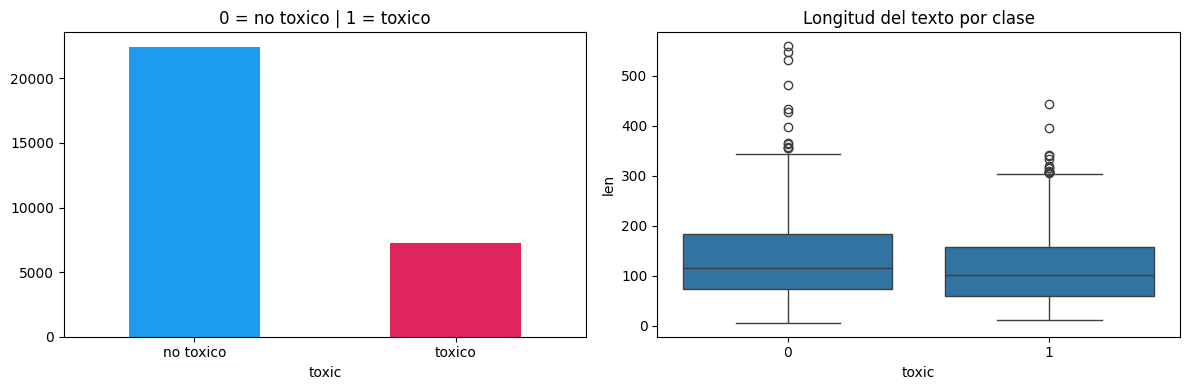

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df = df[df['text'].str.strip()!=''].reset_index(drop=True)
print('Filas:', len(df))
print('Balance de clases:\n', df['toxic'].value_counts())
df['len']=df['text'].str.len()
fig,ax=plt.subplots(1,2,figsize=(12,4))
df['toxic'].value_counts().sort_index().plot(kind='bar',ax=ax[0],color=['#1d9bf0','#e0245e'])
ax[0].set_title('0 = no toxico | 1 = toxico'); ax[0].set_xticklabels(['no toxico','toxico'],rotation=0)
sns.boxplot(data=df,x='toxic',y='len',ax=ax[1]); ax[1].set_title('Longitud del texto por clase')
plt.tight_layout(); plt.show()

## 4. Entrenamiento (TF-IDF + Regresión Logística)

⚠️ Los pasos del Pipeline se llaman **'tfidf'** y **'clf'** — así los espera el microservicio para resaltar palabras. No cambies esos nombres.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Xtr,Xte,ytr,yte = train_test_split(df['text'], df['toxic'], test_size=0.2,
                                   random_state=42, stratify=df['toxic'])
pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True)),
                 ('clf',   LogisticRegression(max_iter=1000, C=4.0, class_weight='balanced'))])
pipe.fit(Xtr, ytr)
pred = pipe.predict(Xte)
print('F1:', round(f1_score(yte,pred),3))
print(classification_report(yte, pred, target_names=['no toxico','toxico']))

F1: 0.657
              precision    recall  f1-score   support

   no toxico       0.90      0.87      0.88      4488
      toxico       0.63      0.68      0.66      1445

    accuracy                           0.83      5933
   macro avg       0.76      0.78      0.77      5933
weighted avg       0.83      0.83      0.83      5933



## 5. Evaluación (matriz de confusión)

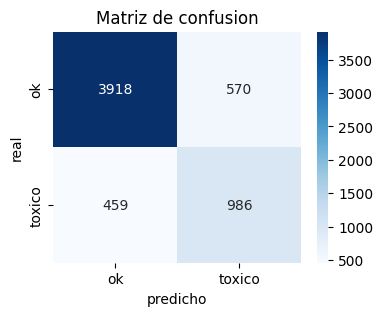

In [8]:
cm=confusion_matrix(yte,pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['ok','toxico'],yticklabels=['ok','toxico'])
plt.ylabel('real'); plt.xlabel('predicho'); plt.title('Matriz de confusion'); plt.show()

## 6. Palabras más tóxicas (interpretación)

In [9]:
vocab=np.array(pipe.named_steps['tfidf'].get_feature_names_out())
coef=pipe.named_steps['clf'].coef_[0]
print('TOP toxicas:', list(vocab[np.argsort(coef)[-20:]][::-1]))
print('\nTOP no toxicas:', list(vocab[np.argsort(coef)[:15]]))

TOP toxicas: ['feminazis', 'zorra', 'feminazi', 'perra', 'payasa', 'puta', 'subnormal', 'patética', 'joto', 'sudacas', 'las feminazis', 'sudaca', 'puto', 'putos', 'pendeja', 'venecos', 'veneco', 'subsaharianos', 'mongolo', 'jotos']

TOP no toxicas: ['ctm', 'culiao', 'nlink', 'aweonao', 'weones', 'chilenos', 'culiaos', 'hijo de', 'pico', 'link link', 'de perra', 'independentista', 'puta madre', 'fachos', 'hijo']


## 7. Probar el modelo

In [10]:
for t in ['gracias por el gran trabajo equipo','eres un idiota, callate']:
    p=pipe.predict_proba([t])[0][1]
    print(f'  toxicidad={p:.0%}  |  {t}')

  toxicidad=12%  |  gracias por el gran trabajo equipo
  toxicidad=55%  |  eres un idiota, callate


## 8. Exportar y descargar el modelo

Se descarga `toxicity_model.pkl`. Cópialo a `ai-service/models/toxicity_model.pkl` de tu proyecto y haz `docker compose restart ai-service`.

In [15]:
# Execute the following code to download the model when the jupiter notebook is running in Google Colab.
# import joblib
# joblib.dump(pipe, 'toxicity_model.pkl')
# from google.colab import files
# files.download('toxicity_model.pkl')
# print('Listo. Coloca el archivo en ai-service/models/ de tu proyecto.')

#Execute the following code to save the model in a local environment
import joblib
joblib.dump(pipe, 'toxicity_model_{0}.pkl'.format(pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")))
print('Listo. Coloca el archivo en ai-service/models/ de tu proyecto.')

Listo. Coloca el archivo en ai-service/models/ de tu proyecto.
